# Rethinking How We Choose Statistical Tests Challenge

## Limitations of RCTs — Simulations

Three interactive simulations illustrating common pitfalls:

1. **The Generalizability Trap** — External validity failure
2. **Small-Sample Power Illusion** — Underpowered RCTs and exaggerated effects
3. **Unstable DGP + Meta-Analysis** — When the truth shifts over time

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Seed for reproducibility
rng = np.random.default_rng(42)

# Colors
MAIN    = '#0056d2'
BG      = '#fffbf5'
TXT     = '#1f1f1c'
TXT_S   = '#4a4a45'
ACC1    = '#6f8a6d'   # green
ACC2    = '#b08a3a'   # gold
ACC3    = '#ab615d'   # rose

In [2]:
def style_ax(ax, title='', xlabel='', ylabel=''):
    """Apply brand styling to an axis."""
    ax.set_facecolor(BG)
    ax.set_title(title, color=TXT, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, color=TXT, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, color=TXT, fontsize=11, fontweight='bold')
    ax.tick_params(colors=TXT_S, labelsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', color='#d6d6d1', lw=0.5, zorder=0)

---
## 1. The Generalizability Trap

**Setup:** A drug has a *heterogeneous* treatment effect:
- **Young patients (age < 40):** large benefit (effect = 5)
- **Older patients (age ≥ 40):** large harm (effect = -5)

The population is 50/50 young and old, so the true *population-average* effect is **0**.

But the RCT recruits primarily from a university hospital → **80% young patients**.

Randomization is perfect. Internal validity is fine. But what happens when we generalize?

In [3]:
# Population params
n_population = 100_000
noise_sd = 4

# True treatment effects by subgroup
effect_young = 5.0
effect_old   = -5.0

# Population is 50/50
is_young_pop = rng.random(n_population) < 0.50
true_effect_pop = np.where(is_young_pop, effect_young, effect_old)
true_population_ate = true_effect_pop.mean()

print(f"True population ATE: {true_population_ate:.2f}")

True population ATE: -0.03


In [9]:
# Run biased-recruitment RCT
n_trial = 200
prob_young_in_trial = 0.8  # university hospital → skewed sample

is_young = rng.random(n_trial) < prob_young_in_trial
treatment = rng.random(n_trial) < 0.5  # perfect randomization

# Generate outcomes
true_effect = np.where(is_young, effect_young, effect_old)
y = np.where(treatment, true_effect, 0) + rng.normal(0, noise_sd, n_trial)

# Estimate ATE from trial
trial_ate = y[treatment].mean() - y[~treatment].mean()

print(f"Trial ATE (biased sample):   {trial_ate:.2f}")
print(f"True population ATE:         {true_population_ate:.2f}")
print(f"Trial % young: {is_young.mean()*100:.0f}%  |  Population % young: 50%")

Trial ATE (biased sample):   3.46
True population ATE:         -0.03
Trial % young: 80%  |  Population % young: 50%


In [10]:
# Repeat 1000 times to see the systematic bias
n_sims = 1000
trial_ates = []
representative_ates = []

for _ in range(n_sims):
    # Biased trial (80% young)
    is_young = rng.random(n_trial) < prob_young_in_trial
    treatment = rng.random(n_trial) < 0.50
    true_eff = np.where(is_young, effect_young, effect_old)
    y = np.where(treatment, true_eff, 0) + rng.normal(0, noise_sd, n_trial)
    trial_ates.append(y[treatment].mean() - y[~treatment].mean())

    # Representative trial (50% young)
    is_young_r = rng.random(n_trial) < 0.50
    treatment_r = rng.random(n_trial) < 0.50
    true_eff_r = np.where(is_young_r, effect_young, effect_old)
    y_r = np.where(treatment_r, true_eff_r, 0) + rng.normal(0, noise_sd, n_trial)
    representative_ates.append(y_r[treatment_r].mean() - y_r[~treatment_r].mean())

trial_ates = np.array(trial_ates)
representative_ates = np.array(representative_ates)

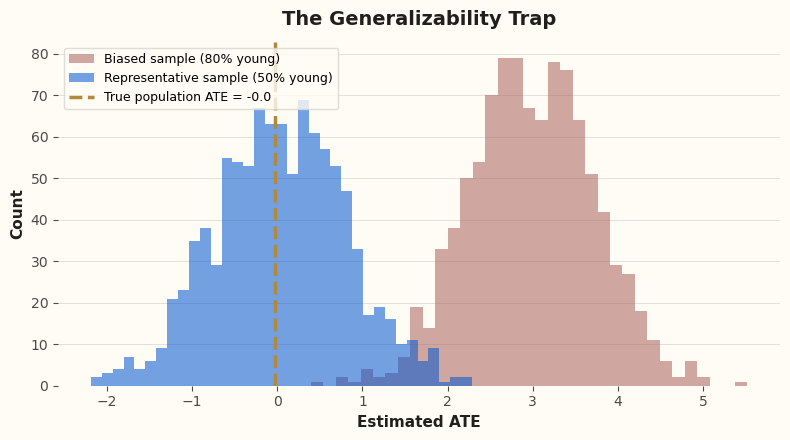

In [11]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)

ax.hist(trial_ates, bins=35, alpha=0.55, color=ACC3, label='Biased sample (80% young)', zorder=2)
ax.hist(representative_ates, bins=35, alpha=0.55, color=MAIN, label='Representative sample (50% young)', zorder=2)
ax.axvline(true_population_ate, color=ACC2, ls='--', lw=2.5, label=f'True population ATE = {true_population_ate:.1f}', zorder=4)

style_ax(ax, 'The Generalizability Trap', 'Estimated ATE', 'Count')
ax.legend(facecolor=BG, edgecolor='#d6d6d1', fontsize=9)
fig.tight_layout()
plt.show()

**Takeaway:** Both RCTs are perfectly randomized. But the biased sample systematically *overestimates* the population-level effect. Randomization solves confounding, not representativeness.

---
## 2. Small-Sample Power Illusion

**Setup:** The true treatment effect is small (Cohen's *d* = 0.3).

We run 1,000 RCTs at three sample sizes: **n = 20**, **n = 50**, **n = 200**.

What do the "significant" results look like?

In [12]:
true_d = 0.3  # small true effect
n_sims = 1000
sample_sizes = [20, 50, 200]
alpha = 0.05

results = {}

for n in sample_sizes:
    estimates = []
    significant = []

    for _ in range(n_sims):
        control   = rng.normal(0,       1, n)
        treatment = rng.normal(true_d,  1, n)

        diff = treatment.mean() - control.mean()
        t_stat, p_val = stats.ttest_ind(treatment, control)

        estimates.append(diff)
        significant.append(p_val < alpha)

    results[n] = {
        'estimates':   np.array(estimates),
        'significant': np.array(significant),
    }

    sig_est = np.array(estimates)[np.array(significant)]
    power = np.mean(significant) * 100
    exaggeration = np.mean(np.abs(sig_est)) / true_d if len(sig_est) > 0 else float('nan')

    print(f"n={n:>3}  |  Power: {power:5.1f}%  |  Mean |significant estimate|/true d: {exaggeration:.2f}x")

n= 20  |  Power:  16.6%  |  Mean |significant estimate|/true d: 2.52x
n= 50  |  Power:  29.5%  |  Mean |significant estimate|/true d: 1.74x
n=200  |  Power:  82.4%  |  Mean |significant estimate|/true d: 1.10x


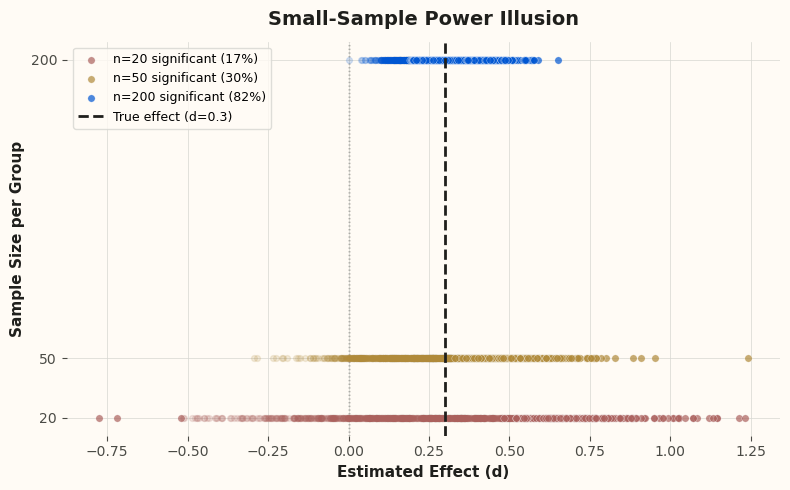

In [14]:
# Funnel plot
colors = {20: ACC3, 50: ACC2, 200: MAIN}

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)

for n in sample_sizes:
    est = results[n]['estimates']
    sig = results[n]['significant']
    se  = 1 / np.sqrt(n)  # approximate SE for display

    ax.scatter(est[~sig], np.full((~sig).sum(), n), color=colors[n],
               alpha=0.15, s=18, zorder=2)
    ax.scatter(est[sig],  np.full(sig.sum(), n),    color=colors[n],
               alpha=0.7,  s=28, zorder=3, edgecolors='white', linewidths=0.3,
               label=f'n={n} significant ({sig.mean()*100:.0f}%)')

ax.axvline(true_d, color=TXT, ls='--', lw=2, label=f'True effect (d={true_d})', zorder=4)
ax.axvline(0, color=TXT_S, ls=':', lw=1, zorder=1)

style_ax(ax, 'Small-Sample Power Illusion', 'Estimated Effect (d)', 'Sample Size per Group')
ax.set_yticks(sample_sizes)
ax.grid(axis='x', color='#d6d6d1', lw=0.5, zorder=0)
ax.legend(facecolor=BG, edgecolor='#d6d6d1', fontsize=9, loc='upper left')
fig.tight_layout()
plt.show()

**Takeaway:** Small underpowered trials that happen to reach significance *systematically overestimate* the true effect (Type M error / winner's curse). The bright dots are "published" results — notice how they cluster *away* from the true effect at small n.

---
## 3. Unstable Data Generating Process + Meta-Analysis

**Setup:** An intervention genuinely works at first (effect = 4.0), but the effect **decays** over time as context shifts (novelty wears off, population adapts, conditions change).

Multiple RCTs are run at different time points. A meta-analysis pools them — but what is it actually estimating?

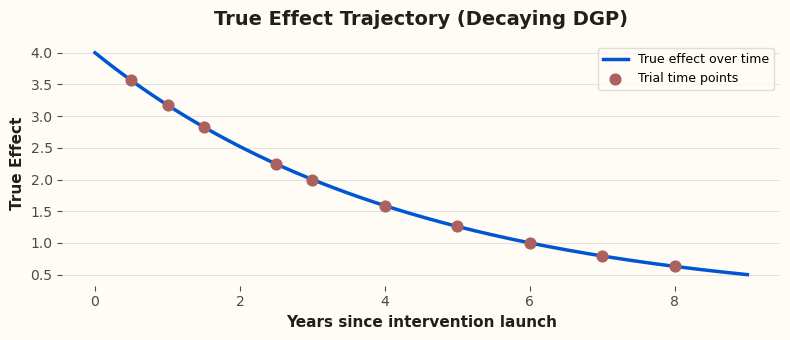

In [15]:
# DGP simulator: effect decays over time
def true_effect_at(time, initial=4.0, half_life=3.0):
    """Treatment effect that decays exponentially."""
    return initial * np.exp(-0.693 * time / half_life)

# Time points when trials are run (in years)
trial_times = np.array([0.5, 1.0, 1.5, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
trial_n     = rng.integers(30, 150, size=len(trial_times))  # varying sample sizes

# Show the true effect trajectory
t_grid = np.linspace(0, 9, 200)
fig, ax = plt.subplots(figsize=(8, 3.5), facecolor=BG)
ax.plot(t_grid, true_effect_at(t_grid), color=MAIN, lw=2.5, label='True effect over time')
ax.scatter(trial_times, true_effect_at(trial_times), color=ACC3, s=60, zorder=5, label='Trial time points')
style_ax(ax, 'True Effect Trajectory (Decaying DGP)', 'Years since intervention launch', 'True Effect')
ax.legend(facecolor=BG, edgecolor='#d6d6d1', fontsize=9)
fig.tight_layout()
plt.show()

In [16]:
# Run each trial
trial_estimates = []
trial_ses = []
trial_pvals = []
noise_sd = 5

for i, (t, n) in enumerate(zip(trial_times, trial_n)):
    true_eff = true_effect_at(t)

    control   = rng.normal(0,        noise_sd, n)
    treatment = rng.normal(true_eff, noise_sd, n)

    diff = treatment.mean() - control.mean()
    se   = np.sqrt(treatment.var()/n + control.var()/n)
    _, p = stats.ttest_ind(treatment, control)

    trial_estimates.append(diff)
    trial_ses.append(se)
    trial_pvals.append(p)

    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"Trial {i+1:>2} (t={t:.1f}y, n={n:>3}): estimate = {diff:>6.2f}  SE = {se:.2f}  p = {p:.4f} {sig}")

trial_estimates = np.array(trial_estimates)
trial_ses = np.array(trial_ses)

Trial  1 (t=0.5y, n= 83): estimate =   3.71  SE = 0.74  p = 0.0000 ***
Trial  2 (t=1.0y, n= 61): estimate =   5.05  SE = 0.87  p = 0.0000 ***
Trial  3 (t=1.5y, n= 48): estimate =   2.61  SE = 1.10  p = 0.0213 *
Trial  4 (t=2.5y, n=141): estimate =   1.59  SE = 0.57  p = 0.0062 **
Trial  5 (t=3.0y, n= 62): estimate =   1.47  SE = 0.85  p = 0.0884 
Trial  6 (t=4.0y, n=108): estimate =   1.57  SE = 0.69  p = 0.0243 *
Trial  7 (t=5.0y, n= 44): estimate =   2.31  SE = 1.12  p = 0.0441 *
Trial  8 (t=6.0y, n= 60): estimate =   1.38  SE = 0.78  p = 0.0838 
Trial  9 (t=7.0y, n= 96): estimate =   0.01  SE = 0.68  p = 0.9883 
Trial 10 (t=8.0y, n= 77): estimate =   0.51  SE = 0.79  p = 0.5214 


In [17]:
# Fixed-effect meta-analysis (inverse-variance weighted)
weights = 1 / trial_ses**2
meta_estimate = np.sum(weights * trial_estimates) / np.sum(weights)
meta_se = np.sqrt(1 / np.sum(weights))
meta_ci_lo = meta_estimate - 1.96 * meta_se
meta_ci_hi = meta_estimate + 1.96 * meta_se

print(f"Meta-analytic estimate: {meta_estimate:.2f} [{meta_ci_lo:.2f}, {meta_ci_hi:.2f}]")
print(f"True effect range over trial period: {true_effect_at(trial_times[-1]):.2f} – {true_effect_at(trial_times[0]):.2f}")
print(f"True effect NOW (t=9): {true_effect_at(9):.2f}")

Meta-analytic estimate: 1.84 [1.36, 2.32]
True effect range over trial period: 0.63 – 3.56
True effect NOW (t=9): 0.50


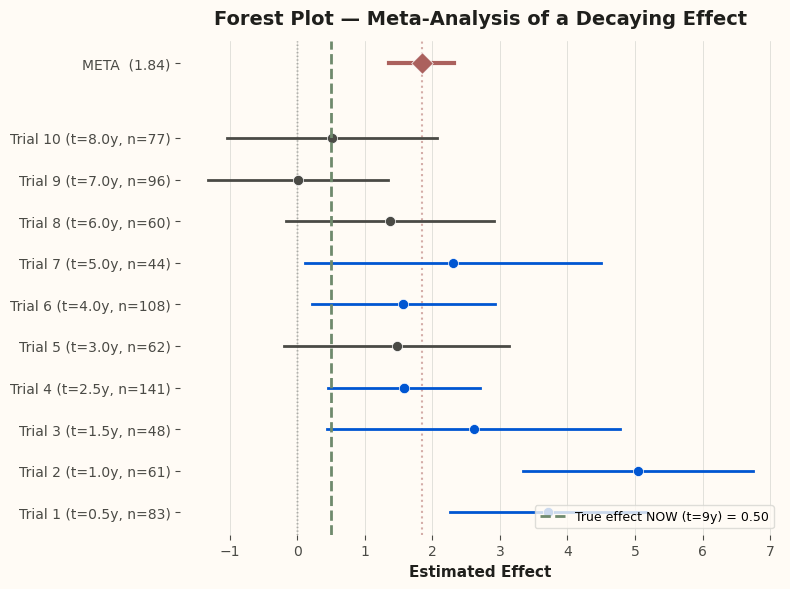

In [18]:
# Forest plot with meta-analysis
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)

y_positions = np.arange(len(trial_times))
y_labels = []

for i in range(len(trial_times)):
    ci_lo = trial_estimates[i] - 1.96 * trial_ses[i]
    ci_hi = trial_estimates[i] + 1.96 * trial_ses[i]

    color = MAIN if trial_pvals[i] < 0.05 else TXT_S
    ax.plot([ci_lo, ci_hi], [i, i], color=color, lw=2, zorder=2)
    ax.scatter(trial_estimates[i], i, color=color, s=50 + weights[i]*2, zorder=3, edgecolors='white', linewidths=0.5)
    y_labels.append(f"Trial {i+1} (t={trial_times[i]:.1f}y, n={trial_n[i]})")

# Meta-analysis diamond
meta_y = len(trial_times) + 0.8
ax.plot([meta_ci_lo, meta_ci_hi], [meta_y, meta_y], color=ACC3, lw=3, zorder=3)
ax.scatter(meta_estimate, meta_y, color=ACC3, s=120, marker='D', zorder=4, edgecolors='white', linewidths=0.5)

# True effect NOW
current_true = true_effect_at(9)
ax.axvline(meta_estimate, color=ACC3, ls=':', lw=1.5, alpha=0.5, zorder=1)
ax.axvline(current_true, color=ACC1, ls='--', lw=2, label=f'True effect NOW (t=9y) = {current_true:.2f}', zorder=4)
ax.axvline(0, color=TXT_S, ls=':', lw=1, zorder=0)

ax.set_yticks(list(y_positions) + [meta_y])
ax.set_yticklabels(y_labels + [f'META  ({meta_estimate:.2f})'], fontsize=9)

style_ax(ax, 'Forest Plot — Meta-Analysis of a Decaying Effect', 'Estimated Effect', '')
ax.grid(axis='x', color='#d6d6d1', lw=0.5, zorder=0)
ax.grid(axis='y', visible=False)
ax.legend(facecolor=BG, edgecolor='#d6d6d1', fontsize=9, loc='lower right')
fig.tight_layout()
plt.show()

**Takeaway:** The meta-analysis produces a precise, confident estimate — but of *what*? The true effect has been decaying the whole time. The pooled estimate is a weighted average over a moving target. By the time the meta-analysis is "done", the real-world effect may be far smaller than what it reports. A stable DGP is an assumption, not a guarantee.